
# Chen-Shu 2015 Fourier-coefficient Gegenbauer reconstruction

This notebook follows Chen and Shu (2015), Section 6, Examples 6.1 and 6.2.
It uses the first `2N+1` Fourier coefficients of endpoint-singular functions and applies the Gegenbauer post-processing reconstruction.

Examples:

- Example 6.1: `u(x) = cos(x) + sin(x) sqrt(1+x)`.
- Example 6.2: `u(x) = cos(x) + sin(x) (1+x)^(1/3)`.



In [1]:

from pathlib import Path
import sys, time
from dataclasses import dataclass

from mpmath import mp
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown

REPO = Path.cwd()
if not (REPO / 'Gegenbauer_Python').exists():
    REPO = Path('/Users/zcq/PaperCode/Recover')
sys.path.insert(0, str(REPO))

from Gegenbauer_Python.gegenbauer_reconstruction import (
    find_best_parameters,
    fourier_coefficients,
    gegenbauer_coefficients_from_fourier,
    mp_format,
    paper_example_function,
    reconstruct_on_y_grid,
)

mp.dps = 70
print('repo =', REPO)
print('mp.dps =', mp.dps)


repo = /Users/zcq/PaperCode/Recover
mp.dps = 70



## Formula implemented

For Examples 6.1 and 6.2, the data are the first `2N+1` Fourier coefficients

$$
\tilde u_k = \frac{1}{2}\int_{-1}^{1}u(x)e^{-ik\pi x}\,dx,\qquad -N\le k\le N,
$$

and the Fourier partial sum is

$$
u_N(x)=\sum_{|k|\le N}\tilde u_k e^{ik\pi x}.
$$

For a singularity exponent `s=p/q`, the same singularity-removing map as the Fortran code is used:

$$
(2^{q-1}(1+x))^{1/q}=1+y,
\quad x(y)=\frac{(1+y)^q}{2^{q-1}}-1.
$$

Then the approximate Gegenbauer coefficients are

$$
\hat g^\lambda_l = \frac{1}{h_l^\lambda}\int_{-1}^{1}
(1-y^2)^{\lambda-1/2}u_N(x(y))C_l^\lambda(y)\,dy,
$$

and the reconstruction is

$$
u_N^{m,\lambda}(x)=\sum_{l=0}^{m}\hat g^\lambda_l C_l^\lambda(y(x)).
$$


In [2]:

@dataclass(frozen=True)
class PaperRow:
    N: int
    linear_error: str
    order: str
    linear_lambda: int
    linear_m: int
    optimal_error: str
    optimal_lambda: int
    optimal_m: int


EXAMPLES = {
    '6.1': {
        'p': 1,
        'q': 2,
        'title': 'Example 6.1: cos(x) + sin(x) sqrt(1+x)',
        'figure_label': 'Fig. 1a',
        # The last two optimal-choice columns in the OCR Markdown are labelled
        # lambda,m, but they match the Fortran output order best pair(m,lambda).
        # The pairs below are stored as lambda,m after swapping that order.
        'rows': [
            PaperRow(40, '5.91e-1', '', '2', '1', '1.21e-3', 18, 8),
            PaperRow(80, '2.95e-1', '1.00', 5, 3, '5.25e-5', 40, 12),
            PaperRow(160, '1.56e-2', '4.25', 10, 6, '5.57e-10', 80, 20),
            PaperRow(320, '1.33e-5', '10.19', 20, 12, '2.75e-11', 51, 22),
            PaperRow(640, '6.46e-12', '20.98', 40, 24, '1.11e-12', 44, 23),
        ],
    },
    '6.2': {
        'p': 1,
        'q': 3,
        'title': 'Example 6.2: cos(x) + sin(x) (1+x)^(1/3)',
        'figure_label': 'Fig. 1b',
        'rows': [
            PaperRow(40, '7.13e-1', '', 5, 1, '1.83e-1', 12, 5),
            PaperRow(80, '3.64e-1', '0.97', 10, 2, '1.98e-2', 33, 7),
            PaperRow(160, '2.91e-1', '0.33', 20, 5, '1.24e-3', 76, 12),
            PaperRow(320, '1.17e-2', '4.64', 40, 10, '5.50e-6', 97, 17),
            PaperRow(640, '1.83e-6', '12.64', 80, 20, '3.15e-7', 89, 21),
        ],
    },
}


@dataclass
class ReconResult:
    example: str
    mode: str
    N: int
    lam: int
    m: int
    max_error: mp.mpf
    mean_error: mp.mpf
    x_at_max: mp.mpf
    x_values: list
    errors: list


def selected_rows(example_key, N_values):
    wanted = set(N_values)
    return [row for row in EXAMPLES[example_key]['rows'] if row.N in wanted]


def compute_order(previous_error, current_error):
    if previous_error is None:
        return ''
    return mp_format(mp.log(previous_error / current_error, 2), 5)


def compute_reconstruction(example_key, N, lam, m, coeffs, mode='linear', nzn=None):
    cfg = EXAMPLES[example_key]
    q = cfg['q']
    func = paper_example_function(cfg['p'], q)
    grid_size = N if nzn is None else nzn
    hg = gegenbauer_coefficients_from_fourier(coeffs, N, m, lam, q)
    x_values, _, approx = reconstruct_on_y_grid(hg, lam, q, grid_size)
    exact = [func(x) for x in x_values]
    errors = [abs(a - e) for a, e in zip(approx, exact)]
    imax = max(range(len(errors)), key=lambda i: errors[i])
    return ReconResult(
        example=example_key,
        mode=mode,
        N=N,
        lam=lam,
        m=m,
        max_error=errors[imax],
        mean_error=mp.fsum(errors) / len(errors),
        x_at_max=x_values[imax],
        x_values=x_values,
        errors=errors,
    )



## Run the tests

To reproduce the full Tables 1 and 2 / Fig. 1 curves, use:

```python
N_VALUES = [40, 80, 160, 320, 640]
```



In [3]:

N_VALUES = [40, 80, 160, 320, 640]
DPS = 70
FOURIER_METHOD = 'gauss3'  # same composite 3-point Gauss integration as the Fortran translation
PANELS = None             # None uses min(100*N, 4000), matching the Fortran code
SEARCH_OPTIMAL = False    # Set True to rescan 1 <= lambda,m <= N/2. Very slow for large N.

mp.dps = DPS
all_rows = []
linear_results = []
optimal_results = []

for example_key in ['6.1', '6.2']:
    previous_linear = None
    cfg = EXAMPLES[example_key]
    func = paper_example_function(cfg['p'], cfg['q'])
    for paper_row in selected_rows(example_key, N_VALUES):
        started = time.time()
        coeffs = fourier_coefficients(func, paper_row.N, method=FOURIER_METHOD, panels=PANELS)
        linear = compute_reconstruction(
            example_key,
            paper_row.N,
            int(paper_row.linear_lambda),
            int(paper_row.linear_m),
            coeffs,
            mode='linear',
        )
        paper_opt = compute_reconstruction(
            example_key,
            paper_row.N,
            int(paper_row.optimal_lambda),
            int(paper_row.optimal_m),
            coeffs,
            mode='paper optimal pair',
        )
        elapsed = time.time() - started
        linear_results.append(linear)
        optimal_results.append(paper_opt)

        row = {
            'Example': example_key,
            'N': paper_row.N,
            'linear_lambda': linear.lam,
            'linear_m': linear.m,
            'computed_linear_Linf': mp_format(linear.max_error, 10),
            'paper_linear_Linf': paper_row.linear_error,
            'linear_ratio': mp_format(linear.max_error / mp.mpf(paper_row.linear_error), 8),
            'computed_order': compute_order(previous_linear, linear.max_error),
            'paper_order': paper_row.order,
            'linear_L1_mean': mp_format(linear.mean_error, 10),
            'linear_x_at_max': mp_format(linear.x_at_max, 10),
            'paper_opt_lambda': paper_opt.lam,
            'paper_opt_m': paper_opt.m,
            'computed_at_paper_opt_Linf': mp_format(paper_opt.max_error, 10),
            'paper_opt_Linf': paper_row.optimal_error,
            'paper_opt_ratio': mp_format(paper_opt.max_error / mp.mpf(paper_row.optimal_error), 8),
            'seconds': f'{elapsed:.1f}',
        }

        if SEARCH_OPTIMAL:
            found = find_best_parameters(
                func,
                paper_row.N,
                cfg['q'],
                max_lam=paper_row.N // 2,
                max_m=paper_row.N // 2,
                dps=DPS,
                fourier_method=FOURIER_METHOD,
                panels=PANELS,
            )
            row.update({
                'searched_opt_lambda': found.best_lam,
                'searched_opt_m': found.best_m,
                'searched_opt_Linf': mp_format(found.max_error, 10),
            })

        all_rows.append(row)
        previous_linear = linear.max_error

headers = list(all_rows[0])
md = '| ' + ' | '.join(headers) + ' |\n'
md += '| ' + ' | '.join(['---'] * len(headers)) + ' |\n'
for row in all_rows:
    md += '| ' + ' | '.join(str(row[h]) for h in headers) + ' |\n'
display(Markdown(md))


| Example | N | linear_lambda | linear_m | computed_linear_Linf | paper_linear_Linf | linear_ratio | computed_order | paper_order | linear_L1_mean | linear_x_at_max | paper_opt_lambda | paper_opt_m | computed_at_paper_opt_Linf | paper_opt_Linf | paper_opt_ratio | seconds |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 6.1 | 40 | 2 | 1 | 0.5910499207 | 5.91e-1 | 1.0000845 |  |  | 0.2554215674 | -1.0 | 18 | 8 | 0.001206409521 | 1.21e-3 | 0.99703266 | 12.2 |
| 6.1 | 80 | 5 | 3 | 0.295264595 | 2.95e-1 | 1.0008969 | 1.0013 | 1.00 | 0.06713201227 | 1.0 | 40 | 12 | 5.25008398e-5 | 5.25e-5 | 1.000016 | 24.0 |
| 6.1 | 160 | 10 | 6 | 0.01555495857 | 1.56e-2 | 0.99711273 | 4.2466 | 4.25 | 0.002345974353 | 1.0 | 80 | 20 | 1.017900873e-10 | 5.57e-10 | 0.18274701 | 50.2 |
| 6.1 | 320 | 20 | 12 | 1.334049034e-5 | 1.33e-5 | 1.0030444 | 10.187 | 10.19 | 2.41054635e-6 | -1.0 | 51 | 22 | 3.470012173e-11 | 2.75e-11 | 1.2618226 | 107.1 |
| 6.1 | 640 | 40 | 24 | 2.998290398e-12 | 6.46e-12 | 0.46413164 | 22.085 | 20.98 | 3.445966075e-13 | -1.0 | 44 | 23 | 1.508331483e-12 | 1.11e-12 | 1.3588572 | 236.1 |
| 6.2 | 40 | 5 | 1 | 0.7131765349 | 7.13e-1 | 1.0002476 |  |  | 0.3840536481 | 0.9182496198 | 12 | 5 | 0.1826543154 | 1.83e-1 | 0.99811101 | 15.3 |
| 6.2 | 80 | 10 | 2 | 0.3644891318 | 3.64e-1 | 1.0013438 | 0.96838 | 0.97 | 0.1120698414 | -1.0 | 33 | 7 | 0.01978669137 | 1.98e-2 | 0.99932785 | 30.8 |
| 6.2 | 160 | 20 | 5 | 0.2909056108 | 2.91e-1 | 0.99967564 | 0.32532 | 0.33 | 0.06361454261 | 1.0 | 76 | 12 | 0.001241664379 | 1.24e-3 | 1.0013422 | 62.0 |
| 6.2 | 320 | 40 | 10 | 0.011702343 | 1.17e-2 | 1.0002003 | 4.6357 | 4.64 | 0.002082786922 | 1.0 | 97 | 17 | 5.501036372e-6 | 5.50e-6 | 1.0001884 | 129.6 |
| 6.2 | 640 | 80 | 20 | 1.827484339e-6 | 1.83e-6 | 0.99862532 | 12.645 | 12.64 | 2.428378702e-7 | 1.0 | 89 | 21 | 3.387982091e-7 | 3.15e-7 | 1.0755499 | 281.6 |


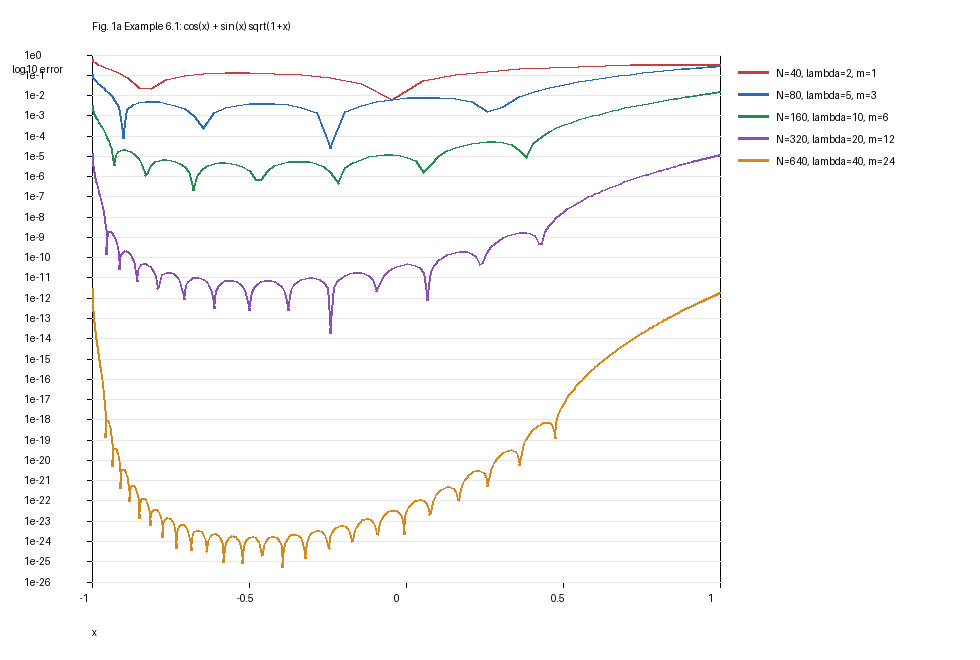

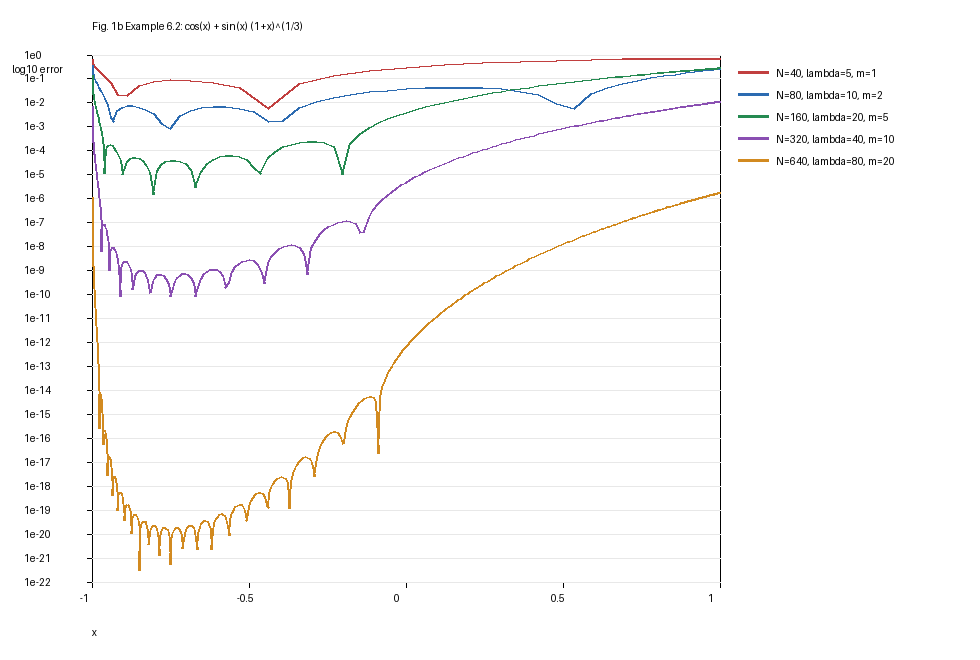

In [4]:

def draw_log_error_plot(results, title, width=980, height=660):
    image = Image.new('RGB', (width, height), 'white')
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()
    left, right, top, bottom = 92, 260, 55, 78
    x0, x1 = left, width - right
    y0, y1 = top, height - bottom
    colors = ['#c13f3f', '#2c6bb1', '#258a51', '#8a4fb2', '#d28a20', '#3b8c91']
    positive = [err for result in results for err in result.errors if err > 0]
    log_min = int(mp.floor(min(mp.log10(err) for err in positive)))
    log_max = int(mp.ceil(max(mp.log10(err) for err in positive)))
    if log_min == log_max:
        log_min -= 1
        log_max += 1
    floor = mp.power(10, log_min)

    def px(x):
        return int(x0 + (x + 1) * (x1 - x0) / 2)

    def py(err):
        value = mp.log10(max(err, floor))
        return int(y1 - (value - log_min) * (y1 - y0) / (log_max - log_min))

    draw.rectangle([x0, y0, x1, y1], outline='black')
    draw.text((x0, 20), title, fill='black', font=font)
    draw.text((x0, height - 34), 'x', fill='black', font=font)
    draw.text((12, y0 + 8), 'log10 error', fill='black', font=font)

    for tick in [-1, -0.5, 0, 0.5, 1]:
        xp = px(mp.mpf(str(tick)))
        draw.line([xp, y1, xp, y1 + 5], fill='black')
        draw.text((xp - 12, y1 + 10), str(tick), fill='black', font=font)

    for exponent in range(log_min, log_max + 1):
        yp = py(mp.power(10, exponent))
        draw.line([x0 - 5, yp, x0, yp], fill='black')
        draw.line([x0, yp, x1, yp], fill='#e8e8e8')
        draw.text((x0 - 68, yp - 6), f'1e{exponent}', fill='black', font=font)

    for idx, result in enumerate(results):
        color = colors[idx % len(colors)]
        ordered = sorted(zip(result.x_values, result.errors), key=lambda item: item[0])
        points = [(px(x), py(error)) for x, error in ordered]
        draw.line(points, fill=color, width=2)
        lx, ly = x1 + 18, y0 + 12 + 22 * idx
        draw.line([lx, ly + 5, lx + 30, ly + 5], fill=color, width=3)
        label = f"N={result.N}, lambda={result.lam}, m={result.m}"
        draw.text((lx + 38, ly), label, fill='black', font=font)
    return image

for example_key in ['6.1', '6.2']:
    subset = [result for result in linear_results if result.example == example_key]
    cfg = EXAMPLES[example_key]
    display(draw_log_error_plot(subset, f"{cfg['figure_label']} {cfg['title']}"))
